In [28]:
import sys
!{sys.executable} -m pip install albumentations opencv-python

In [1]:
pip install torch torchvision timm albumentations opencv-python

In [26]:
pip install albumentations opencv-python


  Using cached albumentations-2.0.8-py3-none-any.whl.metadata (43 kB)
  Using cached albucore-0.0.24-py3-none-any.whl.metadata (5.3 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
Using cached albumentations-2.0.8-py3-none-any.whl (369 kB)
Using cached albucore-0.0.24-py3-none-any.whl (15 kB)
   ---------------------------------------- 0.0/40.1 MB ? eta -:--:--
   - -------------------------------------- 1.3/40.1 MB 9.6 MB/s eta 0:00:05
   ------- -------------------------------- 7.6/40.1 MB 22.4 MB/s eta 0:00:02
   ----------- ---------------------------- 11.5/40.1 MB 25.8 MB/s eta 0:00:02
   ---------------- ----------------------- 16.8/40.1 MB 22.0 MB/s eta 0:00:02
   ------------------ --------------------- 18.6/40.1 MB 19.6 MB/s eta 0:00:02
   --------------------- ------------------ 21.2/40.1 MB 18.1 MB/s eta 0:00:02
   ----------------------- ---------------- 23.6/40.1 MB 17.2 M

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [1]:
import torch
import torch.nn as nn
import os
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


In [10]:
import zipfile
import os

zip_path = "CAMO_COD_generate_99_.zip"
extract_path = "CAMO/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction done!")

Extraction done!


In [11]:
for root, dirs, files in os.walk("CAMO"):
    print(root)

CAMO
CAMO\CAMO_COD_generate_99%
CAMO\CAMO_COD_generate_99%\edge
CAMO\CAMO_COD_generate_99%\image
CAMO\CAMO_COD_generate_99%\mask


In [3]:
import os

for root, dirs, files in os.walk("snapshot"):
    print(root)

snapshot
snapshot\20%
snapshot\20%\CAMO
snapshot\20%\CAMO\.ipynb_checkpoints
snapshot\20%\CHAMELEON
snapshot\20%\COD10K
snapshot\20%\COD10K\.ipynb_checkpoints
snapshot\20%\NC4K


In [4]:
import os

print(os.listdir("snapshot/20%/CAMO"))

['.ipynb_checkpoints', 'camourflage_00012.png', 'camourflage_00018.png', 'camourflage_00061.png', 'camourflage_00064.png', 'camourflage_00071.png', 'camourflage_00079.png', 'camourflage_00087.png', 'camourflage_00088.png', 'camourflage_00090.png', 'camourflage_00097.png', 'camourflage_00098.png', 'camourflage_00100.png', 'camourflage_00102.png', 'camourflage_00112.png', 'camourflage_00114.png', 'camourflage_00120.png', 'camourflage_00122.png', 'camourflage_00124.png', 'camourflage_00129.png', 'camourflage_00135.png', 'camourflage_00138.png', 'camourflage_00141.png', 'camourflage_00145.png', 'camourflage_00147.png', 'camourflage_00153.png', 'camourflage_00156.png', 'camourflage_00160.png', 'camourflage_00166.png', 'camourflage_00169.png', 'camourflage_00171.png', 'camourflage_00175.png', 'camourflage_00183.png', 'camourflage_00196.png', 'camourflage_00197.png', 'camourflage_00205.png', 'camourflage_00207.png', 'camourflage_00208.png', 'camourflage_00209.png', 'camourflage_00224.png', 'c

In [13]:
class CODDataset(Dataset):
    def __init__(self, img_dir):
        self.img_paths = [os.path.join(img_dir, f) for f in os.listdir(img_dir)]
        self.transform = transforms.Compose([
            transforms.Resize((384, 384)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert("RGB")
        return self.transform(img)

dataset = CODDataset("CAMO/CAMO_COD_generate_99%/image")
loader = DataLoader(dataset, batch_size=4, shuffle=True)

print("Total images:", len(dataset))

Total images: 4000


In [14]:
class CODDataset(Dataset):
    def __init__(self, img_dir):
        self.img_paths = [
            os.path.join(img_dir, f)
            for f in os.listdir(img_dir)
            if f.endswith(('.png', '.jpg', '.jpeg'))  # ✅ filter images
        ]

        self.transform = transforms.Compose([
            transforms.Resize((384, 384)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert("RGB")
        return self.transform(img)

4000


(np.float64(-0.5), np.float64(383.5), np.float64(383.5), np.float64(-0.5))

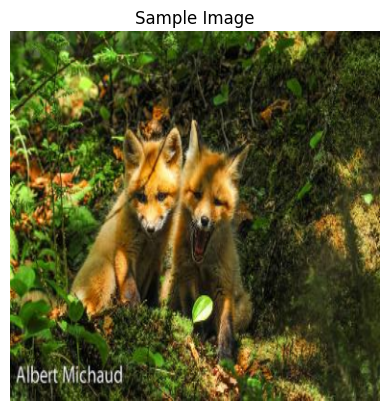

In [16]:
dataset = CODDataset("CAMO/CAMO_COD_generate_99%/image")
print(len(dataset))

img = dataset[0]

plt.imshow(img.permute(1,2,0))
plt.title("Sample Image")
plt.axis('off')

In [20]:
import os

for root, dirs, files in os.walk("Noisy-COD"):
    for file in files:
        if file.endswith(".pth"):
            print(os.path.join(root, file))

In [ ]:
!python code/TrainANet/TrainDDP.py --gpu_id 0 --ration 1

In [17]:
# ===== Universal Noise =====
class UniversalNoise:
    def __init__(self, shape=(3, 384, 384)):
        self.delta = torch.zeros(shape, requires_grad=True, device=DEVICE)

    def apply(self, x):
        delta = self.delta.unsqueeze(0)
        return torch.clamp(x + delta, 0, 1)

noise = UniversalNoise()

optimizer = torch.optim.Adam([noise.delta], lr=1e-2)
criterion = nn.BCELoss()

EPOCHS = 3
LAMBDA = 0.01

In [23]:
import sys
sys.path.append(r"C:\Users\TL1\Noisy-COD\code")

In [24]:
from TrainPNet.lib.Network import Network

C:\Users\TL1\.conda\envs\myexamenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\TL1\.conda\envs\myexamenv\lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
C:\Users\TL1\.conda\envs\myexamenv\lib\site-packages\timm\models\registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


In [29]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import os

class CODDataset(Dataset):
    def __init__(self, img_dir):
        self.img_paths = [
            os.path.join(img_dir, f)
            for f in os.listdir(img_dir)
            if f.endswith(('.png', '.jpg'))
        ]

        self.transform = transforms.Compose([
            transforms.Resize((384, 384)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert("RGB")
        return self.transform(img)

In [30]:
dataset = CODDataset(r"C:\Users\TL1\Noisy-COD\CAMO\CAMO_COD_generate_99%\image")

print("Dataset size:", len(dataset))

Dataset size: 4000


(np.float64(-0.5), np.float64(383.5), np.float64(383.5), np.float64(-0.5))

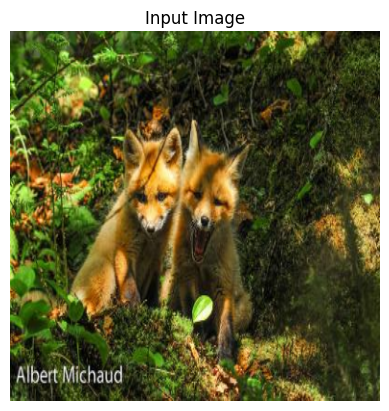

In [31]:
import matplotlib.pyplot as plt

img = dataset[0]

plt.imshow(img.permute(1,2,0))
plt.title("Input Image")
plt.axis('off')

In [26]:
import sys

sys.path.append(r"C:\Users\TL1\Noisy-COD\code")

from TrainPNet.lib.Network import Network

model = Network()
print("Model created")

pvt v2 b4 loaded!
Model created


In [27]:
import torch

weights = torch.load(r"C:\Users\TL1\Noisy-COD\Net_epoch_best.pth", map_location="cpu")

# Fix "module." issue
weights_dict = {}
for k, v in weights.items():
    new_k = k.replace('module.', '') if 'module' in k else k
    weights_dict[new_k] = v

model.load_state_dict(weights_dict)

model.eval()

print("Model + weights loaded")

Model + weights loaded


In [32]:
img = dataset[0].unsqueeze(0)

out = model(img)

if isinstance(out, (list, tuple)):
    out = out[4]

print(out.shape)

C:\Users\TL1\Noisy-COD\code\TrainPNet\lib\Network.py:258: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  [f1, F.upsample(f2, size=f1.shape[2:], mode='bilinear', align_corners=True),
C:\Users\TL1\Noisy-COD\code\TrainPNet\lib\Network.py:259: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  F.upsample(f3, size=f1.shape[2:], mode='bilinear', align_corners=True),
C:\Users\TL1\Noisy-COD\code\TrainPNet\lib\Network.py:260: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  F.upsample(f4, size=f1.shape[2:], mode='bilinear', align_corners=True)], 1))


torch.Size([1, 1, 384, 384])


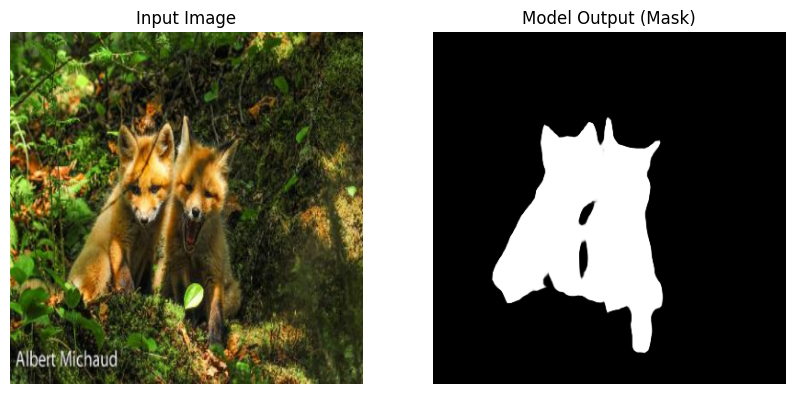

In [33]:
import matplotlib.pyplot as plt
import torch

# Get image
img = dataset[0].unsqueeze(0)

# Model forward
out = model(img)

if isinstance(out, (list, tuple)):
    out = out[4]

out = torch.sigmoid(out).detach().squeeze()

# Convert image for plotting
img_np = img.squeeze().permute(1,2,0).numpy()
out_np = out.numpy()

# Plot
plt.figure(figsize=(10,5))

# Input image
plt.subplot(1,2,1)
plt.imshow(img_np)
plt.title("Input Image")
plt.axis('off')

# Model output
plt.subplot(1,2,2)
plt.imshow(out_np, cmap='gray')
plt.title("Model Output (Mask)")
plt.axis('off')

plt.show()

In [35]:
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

noise = torch.zeros((3, 384, 384), requires_grad=True, device=DEVICE)

optimizer = torch.optim.Adam([noise], lr=1e-2)
criterion = torch.nn.BCELoss()

print(" Noise initialized")

 Noise initialized


In [36]:
from torch.utils.data import DataLoader

loader = DataLoader(dataset, batch_size=4, shuffle=True)

In [38]:
model = model.to(DEVICE)

In [39]:
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = Network()

weights = torch.load(r"C:\Users\TL1\Noisy-COD\Net_epoch_best.pth", map_location=DEVICE)

weights_dict = {}
for k, v in weights.items():
    new_k = k.replace('module.', '') if 'module' in k else k
    weights_dict[new_k] = v

model.load_state_dict(weights_dict)

model = model.to(DEVICE)   # 🔥 THIS WAS MISSING

model.eval()

for p in model.parameters():
    p.requires_grad = False

print(" Model ready on", DEVICE)

pvt v2 b4 loaded!
 Model ready on cuda


In [40]:
EPOCHS = 3
LAMBDA = 0.01

for epoch in range(EPOCHS):
    total_loss = 0

    for imgs in loader:
        imgs = imgs.to(DEVICE)

        # Apply universal noise
        imgs_adv = torch.clamp(imgs + noise.unsqueeze(0), 0, 1)

        # Forward pass
        outputs = model(imgs_adv)

        if isinstance(outputs, (list, tuple)):
            outputs = outputs[4]

        outputs = torch.sigmoid(outputs)

        # Target = zero mask (we want model to fail)
        targets = torch.zeros_like(outputs)

        attack_loss = criterion(outputs, targets)
        camo_loss = torch.norm(noise)

        loss = attack_loss + LAMBDA * camo_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 701.0907
Epoch 2, Loss: 835.1763
Epoch 3, Loss: 675.6198


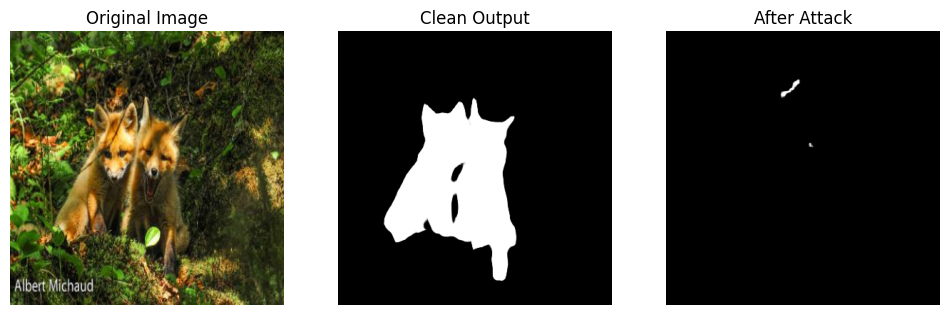

In [41]:
img = dataset[0].unsqueeze(0).to(DEVICE)

# Clean output
clean_out = model(img)
if isinstance(clean_out, (list, tuple)):
    clean_out = clean_out[4]
clean_out = torch.sigmoid(clean_out).detach().cpu().squeeze()

# Apply attack
adv_img = torch.clamp(img + noise.unsqueeze(0), 0, 1)

adv_out = model(adv_img)
if isinstance(adv_out, (list, tuple)):
    adv_out = adv_out[4]
adv_out = torch.sigmoid(adv_out).detach().cpu().squeeze()

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.imshow(img.squeeze().permute(1,2,0).cpu())
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(clean_out, cmap='gray')
plt.title("Clean Output")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(adv_out, cmap='gray')
plt.title("After Attack")
plt.axis('off')

plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6771145..0.76433533].


(np.float64(-0.5), np.float64(383.5), np.float64(383.5), np.float64(-0.5))

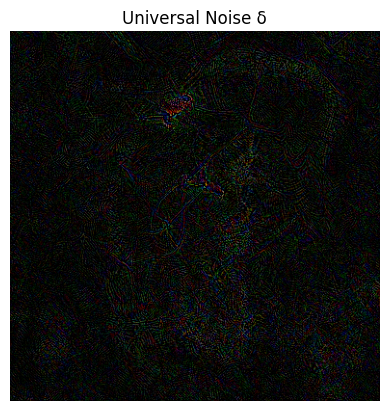

In [42]:
noise_vis = noise.detach().cpu().permute(1,2,0)

plt.imshow(noise_vis)
plt.title("Universal Noise δ")
plt.axis('off')

In [43]:
def get_score(mask):
    return mask.mean().item()

print("Clean score:", get_score(clean_out))
print("Attack score:", get_score(adv_out))

Clean score: 0.17503507435321808
Attack score: 0.0011617087293416262


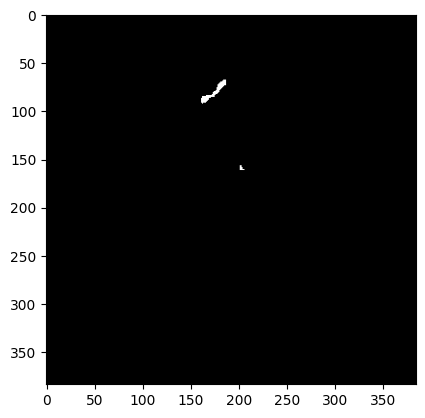

In [44]:
plt.imshow(adv_out > 0.5, cmap='gray')

In [45]:
for i in range(5):
    img = dataset[i].unsqueeze(0).to(DEVICE)

    clean_out = model(img)[4]
    clean_out = torch.sigmoid(clean_out).detach().cpu()

    adv_img = torch.clamp(img + noise.unsqueeze(0), 0, 1)
    adv_out = model(adv_img)[4]
    adv_out = torch.sigmoid(adv_out).detach().cpu()

    print(f"Image {i}: Clean mean = {clean_out.mean():.3f}, Attack mean = {adv_out.mean():.3f}")

Image 0: Clean mean = 0.175, Attack mean = 0.001
Image 1: Clean mean = 0.039, Attack mean = 0.000
Image 2: Clean mean = 0.188, Attack mean = 0.001
Image 3: Clean mean = 0.091, Attack mean = 0.001
Image 4: Clean mean = 0.052, Attack mean = 0.000


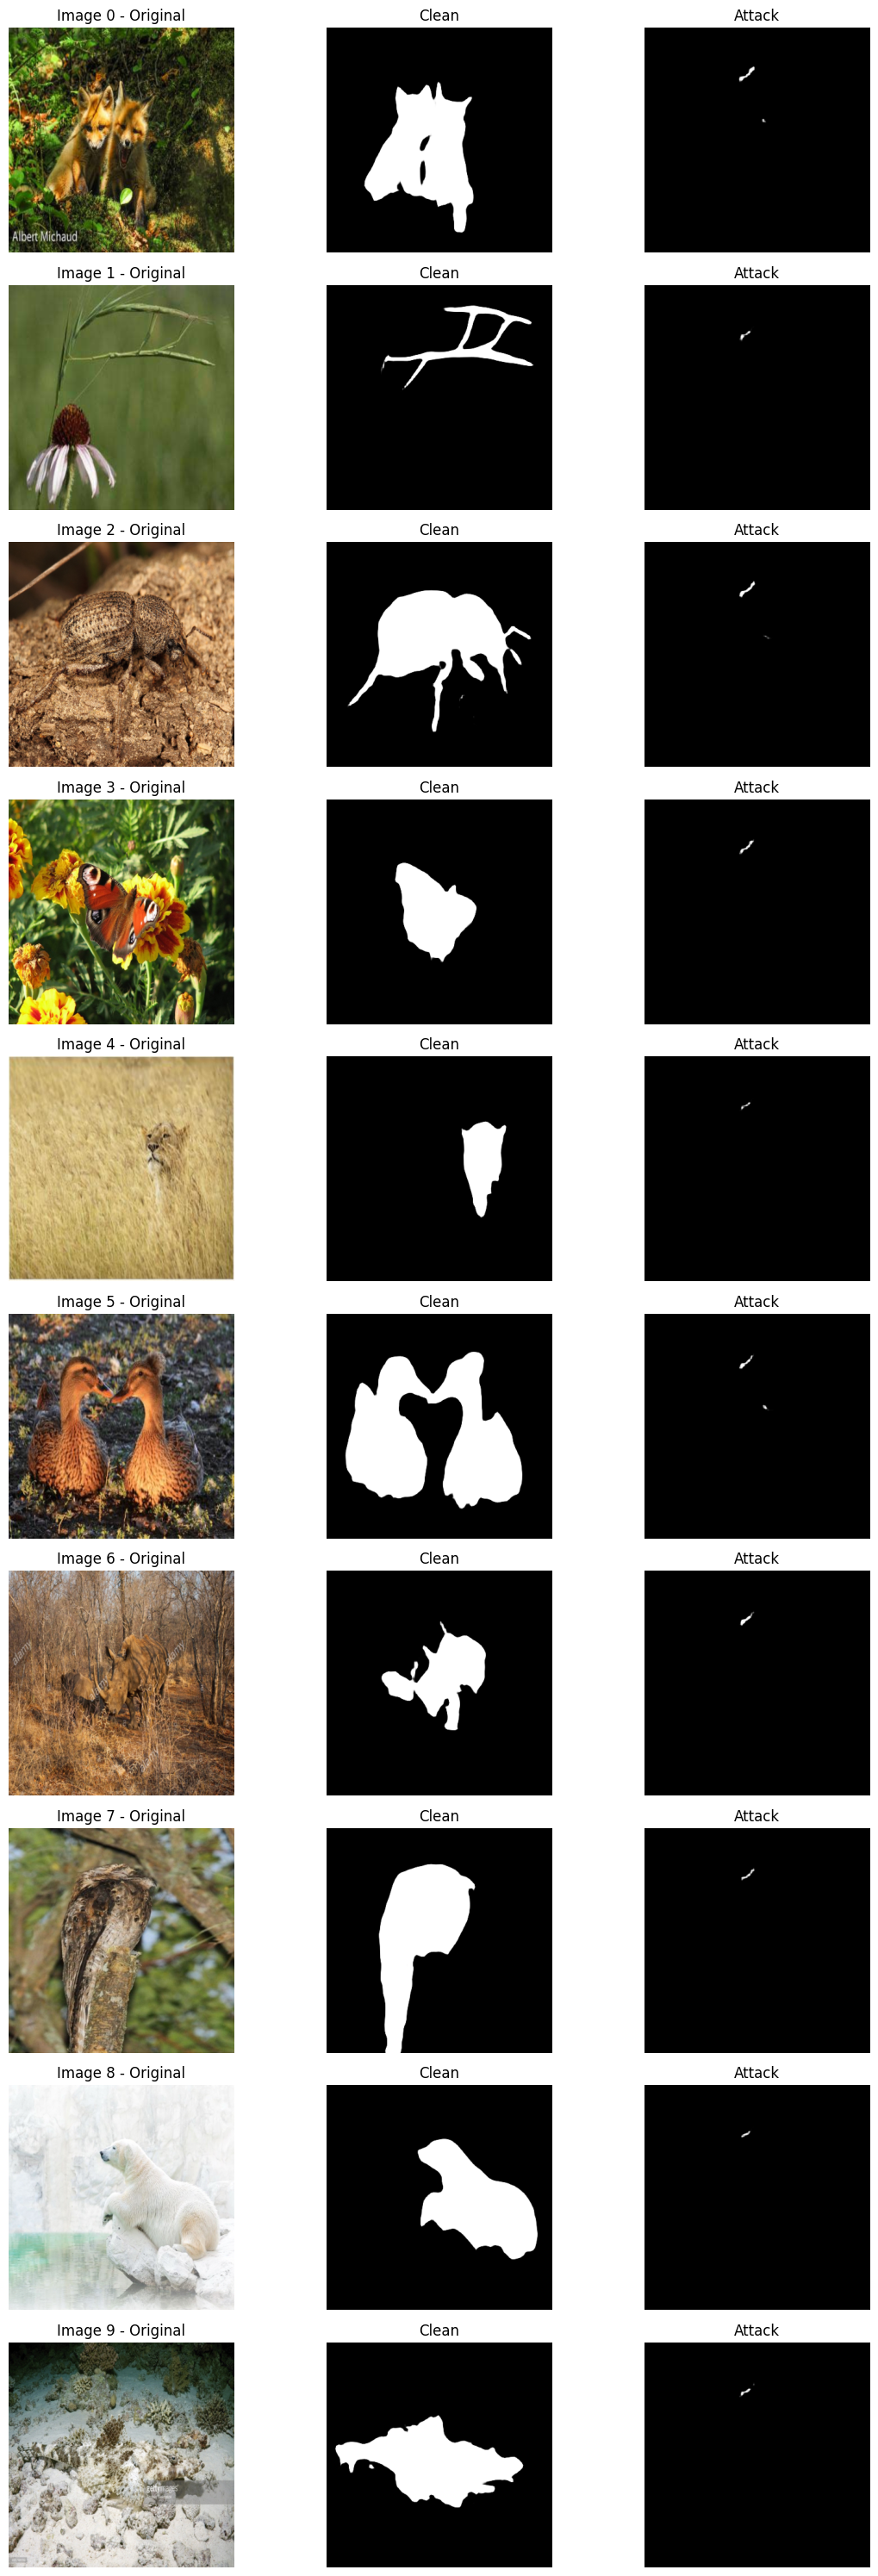

In [46]:
import matplotlib.pyplot as plt
import torch

num_images = 10

plt.figure(figsize=(12, num_images * 3))

for i in range(num_images):
    img = dataset[i].unsqueeze(0).to(DEVICE)

    # Clean output
    clean_out = model(img)
    if isinstance(clean_out, (list, tuple)):
        clean_out = clean_out[4]
    clean_out = torch.sigmoid(clean_out).detach().cpu().squeeze()

    # Attack
    adv_img = torch.clamp(img + noise.unsqueeze(0), 0, 1)

    adv_out = model(adv_img)
    if isinstance(adv_out, (list, tuple)):
        adv_out = adv_out[4]
    adv_out = torch.sigmoid(adv_out).detach().cpu().squeeze()

    # Convert image for plotting
    img_np = img.squeeze().permute(1,2,0).cpu().numpy()

    # Row layout: Original | Clean | Attack
    plt.subplot(num_images, 3, i*3 + 1)
    plt.imshow(img_np)
    plt.title(f"Image {i} - Original")
    plt.axis('off')

    plt.subplot(num_images, 3, i*3 + 2)
    plt.imshow(clean_out, cmap='gray')
    plt.title("Clean")
    plt.axis('off')

    plt.subplot(num_images, 3, i*3 + 3)
    plt.imshow(adv_out, cmap='gray')
    plt.title("Attack")
    plt.axis('off')

plt.tight_layout()
plt.show()